In [ ]:
import numpy as np
import os
import glob
import cv2
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from keras.utils import to_categorical


In [ ]:
!pip install kagglehub -q

In [ ]:
import kagglehub
base_path = kagglehub.dataset_download("sovitrath/water-bodies-segmentation-dataset-with-split")

train_img_dir = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'train_images')
train_mask_dir = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'train_masks')
valid_img_dir = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'valid_images')
valid_mask_dir = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'valid_masks')

all_images_train = sorted(glob.glob(os.path.join(train_img_dir, '*.jpg')))[:500]  # exactly 1000
all_masks_train = sorted(glob.glob(os.path.join(train_mask_dir, '*.jpg')))[:500]

val_images = sorted(glob.glob(os.path.join(valid_img_dir, '*.jpg')))
val_masks = sorted(glob.glob(os.path.join(valid_mask_dir, '*.jpg')))

print(f"Train images: {len(all_images_train)}")
print(f"Train masks : {len(all_masks_train)}")
print(f"Valid images: {len(val_images)}")
print(f"Valid masks : {len(val_masks)}")


Train images: 500
Train masks : 500
Valid images: 158
Valid masks : 158


In [ ]:
IMG_HEIGHT, IMG_WIDTH = 256, 256
NUM_CLASSES = 7

# Define RGB class mappings
urban_land = [0, 255, 255]
agriculture_land = [255, 255, 0]
rangeland = [255, 0, 255]
forest_land = [0, 255, 0]
water = [0, 0, 255]
barren_land = [255, 255, 255]
unknown = [0, 0, 0]

def rgb_to_2D_label(label):
    label_seg = np.zeros(label.shape, dtype=np.uint8)
    label_seg[np.all(label == urban_land, axis=-1)] = 0
    label_seg[np.all(label == agriculture_land, axis=-1)] = 1
    label_seg[np.all(label == rangeland, axis=-1)] = 2
    label_seg[np.all(label == forest_land, axis=-1)] = 3
    label_seg[np.all(label == water, axis=-1)] = 4
    label_seg[np.all(label == barren_land, axis=-1)] = 5
    label_seg[np.all(label == unknown, axis=-1)] = 6
    return label_seg[:, :, 0]


preprocessing training data

In [ ]:
train_images = []
train_masks = []


for img_path, mask_path in zip(all_images_train, all_masks_train):
    # Load and resize image
    img = cv2.imread(img_path, 1)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0  # normalize
    train_images.append(img)

    # Load and convert mask
    mask = cv2.imread(mask_path, 1)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    label = rgb_to_2D_label(mask)
    train_masks.append(label)

train_images = np.array(train_images)
train_masks = np.array(train_masks)
train_masks = np.expand_dims(train_masks, axis=-1)
train_masks_cat = to_categorical(train_masks, num_classes=NUM_CLASSES)


In [ ]:
val_images_data = []
val_masks_data = []
#pre-processing validation data
for img_path, mask_path in zip(val_images, val_masks):
    # Load and resize image
    img = cv2.imread(img_path, 1)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0
    val_images_data.append(img)

    # Load and convert mask
    mask = cv2.imread(mask_path, 1)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    label = rgb_to_2D_label(mask)
    val_masks_data.append(label)

val_images_data = np.array(val_images_data)
val_masks_data = np.array(val_masks_data)
val_masks_data = np.expand_dims(val_masks_data, axis=-1)
val_masks_cat = to_categorical(val_masks_data, num_classes=NUM_CLASSES)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.optimizers import Adam

def unet_model(input_size=(256, 256, 3), num_classes=7):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bridge
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    # Output layer
    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


In [ ]:
model = unet_model(input_size=(256, 256, 3), num_classes=NUM_CLASSES)
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_38[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_40[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ conv2d_41[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_42[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 32, 32,    │          0 │ conv2d_43[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_10… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ conv2d_44[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 16, 16,    │          0 │ conv2d_45[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_11… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 16, 16,    │  9,438,208 │ conv2d_46[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 32, 32,    │  2,097,664 │ conv2d_47[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 31,032,135 (118.38 MB)

 Trainable params: 31,032,135 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(train_images, train_masks_cat,
          validation_data=(val_images_data, val_masks_cat),
          batch_size=2,
          epochs=30,
          callbacks=[early_stop],
          verbose=2)

Epoch 1/30
250/250 - 40s - 160ms/step - accuracy: 0.8871 - loss: 0.2479 - val_accuracy: 0.7775 - val_loss: 0.8297
Epoch 2/30
250/250 - 40s - 160ms/step - accuracy: 0.8886 - loss: 0.2398 - val_accuracy: 0.7735 - val_loss: 0.8560
Epoch 3/30
250/250 - 40s - 161ms/step - accuracy: 0.8898 - loss: 0.2351 - val_accuracy: 0.7804 - val_loss: 0.8486
Epoch 4/30
250/250 - 41s - 163ms/step - accuracy: 0.8906 - loss: 0.2308 - val_accuracy: 0.7695 - val_loss: 0.8767
Epoch 5/30
250/250 - 41s - 164ms/step - accuracy: 0.8897 - loss: 0.2340 - val_accuracy: 0.7859 - val_loss: 0.8115
Epoch 6/30
250/250 - 41s - 164ms/step - accuracy: 0.8263 - loss: 0.4556 - val_accuracy: 0.7802 - val_loss: 0.6791
Epoch 7/30
250/250 - 41s - 163ms/step - accuracy: 0.8827 - loss: 0.2667 - val_accuracy: 0.7847 - val_loss: 0.8023
Epoch 8/30
250/250 - 38s - 153ms/step - accuracy: 0.8896 - loss: 0.2363 - val_accuracy: 0.7794 - val_loss: 0.8452
Epoch 9/30
250/250 - 41s - 164ms/step - accuracy: 0.8915 - loss: 0.2258 - val_accuracy: 

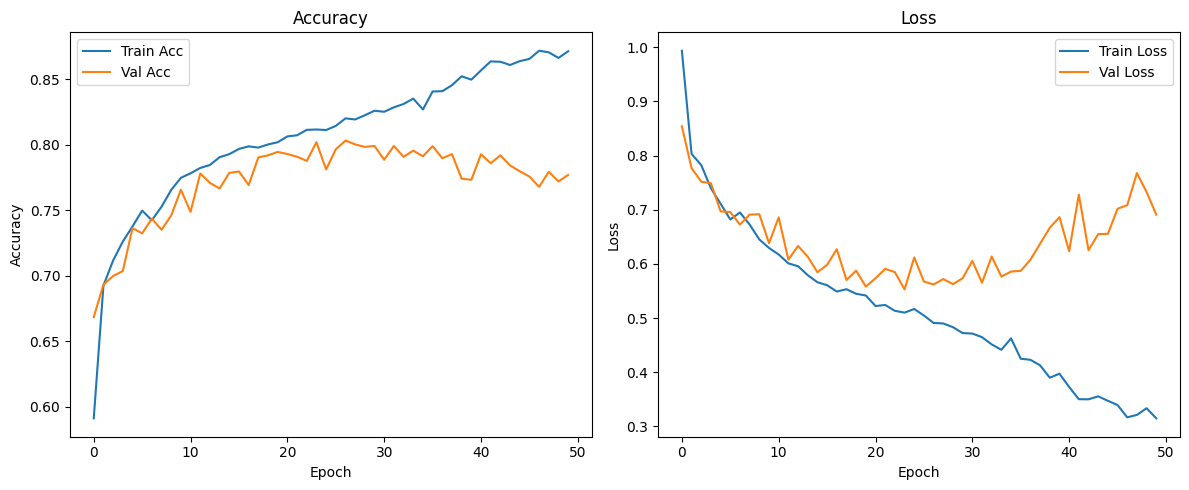

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


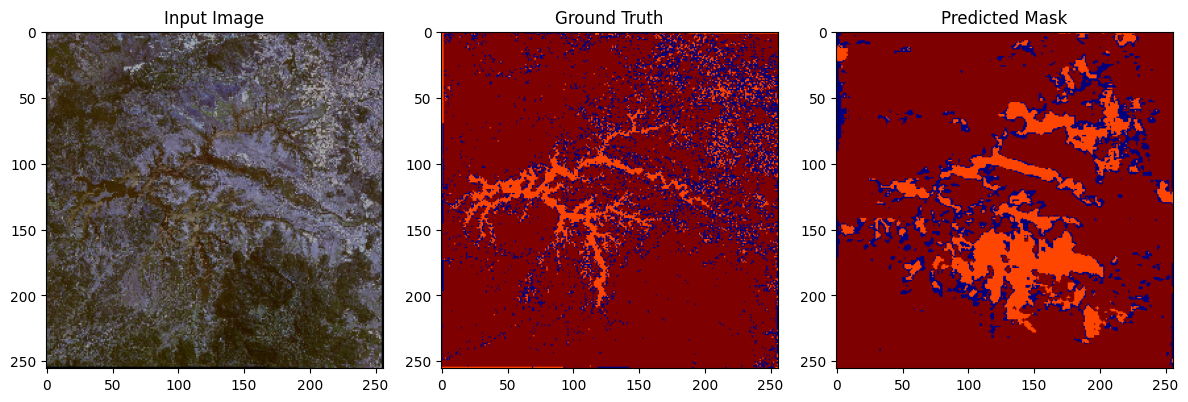

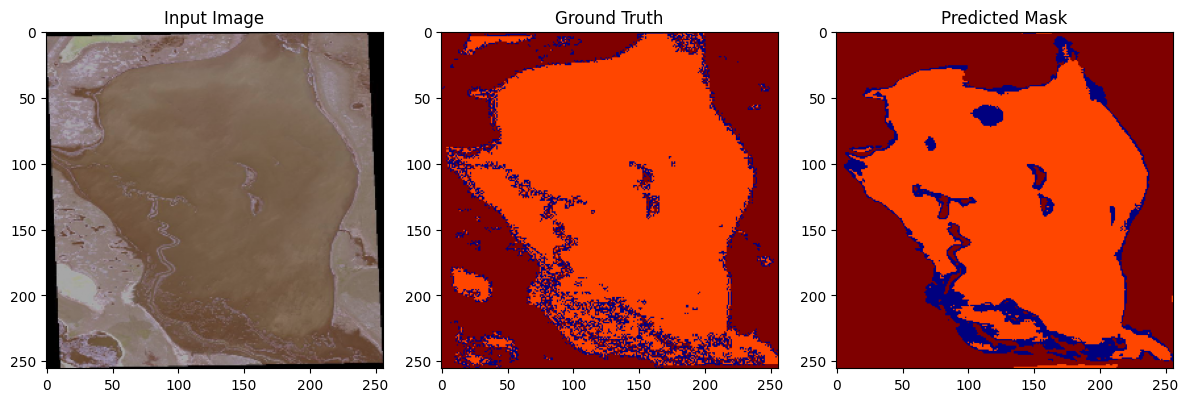

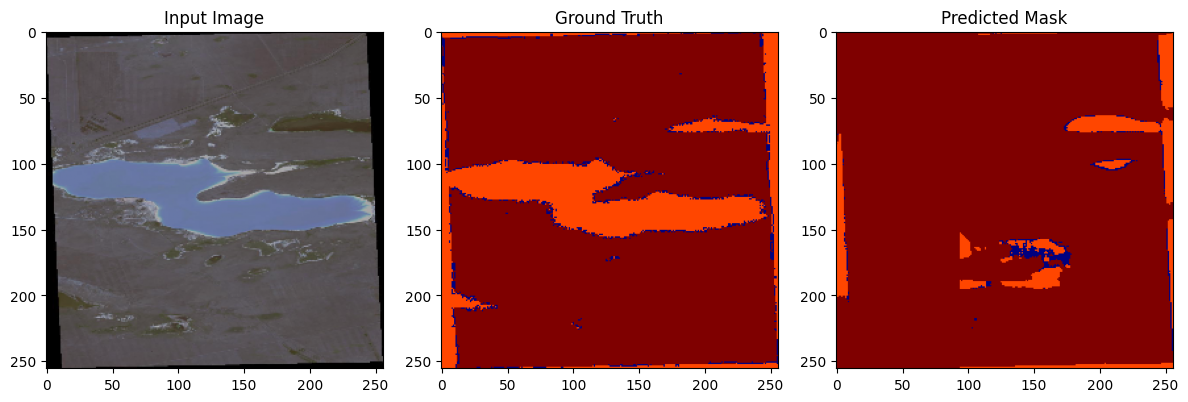

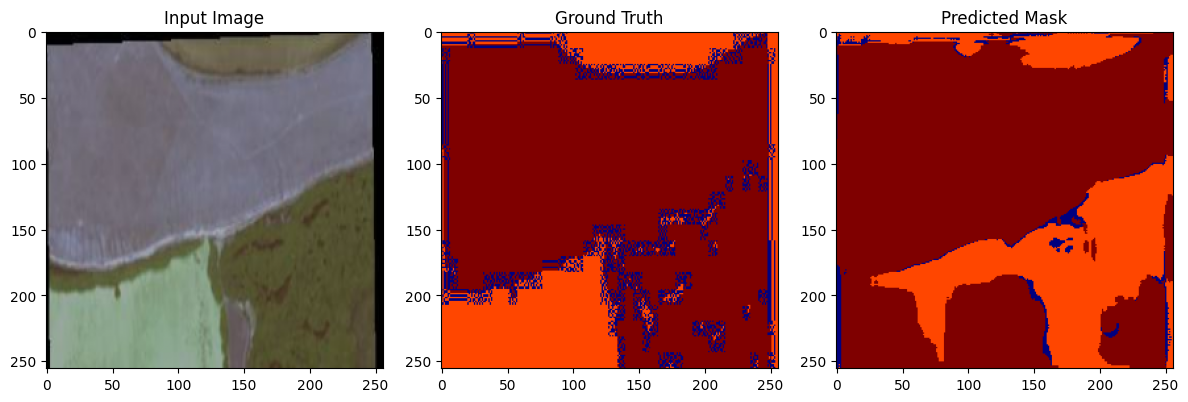

In [ ]:
# ================== PLOT ACCURACY & LOSS ==================
import os, glob, cv2, numpy as np, matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))



plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ================== PREDICT & VISUALIZE ==================
def predict_and_visualize(model, images, masks, num_samples=4):
    predictions = model.predict(images[:num_samples])
    predictions = np.argmax(predictions, axis=-1)
    masks = np.argmax(masks[:num_samples], axis=-1)

    for i in range(num_samples):
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(images[i])
        plt.title("Input Image")

        plt.subplot(1, 3, 2)
        plt.imshow(masks[i], cmap='jet')
        plt.title("Ground Truth")

        plt.subplot(1, 3, 3)
        plt.imshow(predictions[i], cmap='jet')
        plt.title("Predicted Mask")

        plt.tight_layout()
        plt.show()

predict_and_visualize(model, val_images_data, val_masks_cat, num_samples=4)

In [ ]:
# Predict on a few images
predictions = model.predict(val_images_data[:4])  # or any batch
predicted_classes = np.argmax(predictions, axis=-1)  # shape: (batch, H, W)

# Get the unique classes predicted across all pixels and images
unique_classes = np.unique(predicted_classes)

print("Classes predicted by the model:", unique_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Classes predicted by the model: [0 5 6]
